# Decision Intelligence Assistant
## Feature Engineering & ML Model Training

**Goal:** Build meaningful features from tweet text and train multiple 
ML classifiers to predict ticket priority (urgent vs normal).

**Pipeline:**
1. RoBERTa sentiment (deep learning, GPU-accelerated)
2. Hand-crafted features (12 domain-specific signals)
3. TF-IDF features (200 automatic text patterns)
4. PCA dimensionality reduction (50 components)
5. Train & compare multiple ML models
6. Save best model for API serving

## 1. Imports & Setup
All libraries, models, and keyword sets needed throughout this notebook.

In [6]:
# ── Standard Libraries ───────────────────────────────────────────────────────
import re
import html
import emoji
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import time
warnings.filterwarnings('ignore')

# ── ML Libraries ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, f1_score, roc_auc_score)
from scipy.sparse import hstack, csr_matrix

# ── ML Models ────────────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# ── NLP Libraries ────────────────────────────────────────────────────────────
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from scipy.special import softmax
import torch

print("All imports successful")

All imports successful


### 1.1 Load NLP Models

In [7]:
# ── VADER Setup ───────────────────────────────────────────────────────────────
vader_analyzer = SentimentIntensityAnalyzer()
print("VADER loaded")

# ── RoBERTa Setup ─────────────────────────────────────────────────────────────
MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment"
print(f"Loading RoBERTa model: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
roberta_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Move to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
roberta_model = roberta_model.to(device)
roberta_model.eval()

print(f"RoBERTa loaded on: {device}")

VADER loaded
Loading RoBERTa model: cardiffnlp/twitter-roberta-base-sentiment


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RoBERTa loaded on: cuda


### 1.2 Keyword Sets
Domain-specific keyword sets for hand-crafted features.

In [8]:
# ── Keyword Sets ──────────────────────────────────────────────────────────────
PROBLEM_KEYWORDS = {
    "not working", "broken", "failed", "fail", "error", "issue",
    "problem", "bug", "crash", "crashed", "outage", "offline",
    "unavailable", "unable", "cannot", "can't", "wont", "won't",
    "locked", "blocked", "banned", "suspended", "lost access",
    "hacked", "compromised", "not loading", "freezing", "frozen",
    "stuck", "terrible", "awful", "horrible", "worst", "unacceptable",
    "ridiculous", "disgusting", "useless", "pathetic", "disappointed",
    "frustrated", "angry", "furious", "fed up", "sick of", "tired of"
}

FINANCIAL_KEYWORDS = {
    "refund", "charged", "overcharged", "stolen", "fraud", "scam",
    "unauthorized", "double charged", "wrong charge"
}

SERVICE_DOWN_KEYWORDS = {
    "no service", "no signal", "no internet", "no connection",
    "disconnected", "complete outage", "totally down", "not available"
}

URGENT_EMOJIS = {
    ":enraged_face:", ":angry_face:", ":face_with_symbols_on_mouth:",
    ":crying_face:", ":loudly_crying_face:", ":broken_heart:",
    ":fire:", ":sos:", ":warning:", ":red_circle:", ":skull:",
    ":face_screaming_in_fear:", ":weary_face:", ":tired_face:",
    ":disappointed_face:", ":thumbs_down:"
}
NEGATIONS = {
    "not", "never", "no", "fixed", "resolved", "working now",
    "don't", "didn't", "doesn't", "wasn't", "weren't", "won't",
    "can't", "couldn't", "shouldn't", "wouldn't", "neither",
    "nor", "hardly", "barely", "scarcely"
}

INTENSIFIERS = {
    "very", "extremely", "completely", "totally", "absolutely",
    "really", "so", "super", "incredibly", "unbelievably",
    "terribly", "awfully", "dreadfully", "highly", "deeply",
    "utterly", "severely", "seriously", "badly", "greatly",
    "immensely", "overwhelmingly", "beyond", "insanely"
}

TIME_PRESSURE = {
    "still", "days", "hours", "weeks", "months", "since",
    "already", "yet", "again", "repeatedly", "multiple times",
    "third time", "second time", "keep", "keeps", "kept",
    "ongoing", "continues", "persistent", "never resolved",
    "always", "every time", "each time", "constantly",
    "forever", "ages", "long time", "waiting", "waited"
}
print(f"PROBLEM_KEYWORDS: {len(PROBLEM_KEYWORDS)} keywords")
print(f"FINANCIAL_KEYWORDS: {len(FINANCIAL_KEYWORDS)} keywords")
print(f"SERVICE_DOWN_KEYWORDS: {len(SERVICE_DOWN_KEYWORDS)} keywords")
print(f"URGENT_EMOJIS: {len(URGENT_EMOJIS)} emojis")
print(f"NEGATIONS: {len(NEGATIONS)} keywords")
print(f"INTENSIFIERS: {len(INTENSIFIERS)} keywords")
print(f"TIME_PRESSURE: {len(TIME_PRESSURE)} keywords")

PROBLEM_KEYWORDS: 45 keywords
FINANCIAL_KEYWORDS: 9 keywords
SERVICE_DOWN_KEYWORDS: 8 keywords
URGENT_EMOJIS: 16 emojis
NEGATIONS: 21 keywords
INTENSIFIERS: 24 keywords
TIME_PRESSURE: 29 keywords


### 1.3 Helper Functions

In [9]:
# ── Helper Functions ──────────────────────────────────────────────────────────

def is_negated(text, keyword):
    """Check if keyword is preceded by a negation within 3 words"""
    words = text.split()
    for i, word in enumerate(words):
        if keyword in word:
            window = words[max(0, i-3):i]
            if any(neg in window for neg in NEGATIONS):
                return True
    return False

def has_intensified_keyword(text, keywords):
    """Check if an intensifier appears before a keyword"""
    words = text.split()
    for i, word in enumerate(words):
        if word in INTENSIFIERS and i + 1 < len(words):
            next_words = ' '.join(words[i+1:i+4])
            if any(kw in next_words for kw in keywords):
                return True
    return False

def has_repetition(text):
    """Detect repeated words - sign of frustration"""
    return bool(re.search(r'\b(\w+)\b.*\b\1\b.*\b\1\b', text))

def has_urgent_question(text):
    """Detect urgent questions with time pressure"""
    if '?' in text:
        has_problem = any(kw in text for kw in PROBLEM_KEYWORDS)
        has_time = any(tp in text for tp in TIME_PRESSURE)
        return has_problem and has_time
    return False

print("Helper functions loaded")

Helper functions loaded


## 2. Load Data

In [6]:
# ── Load Processed Dataset ────────────────────────────────────────────────────
df = pd.read_csv('../data/processed/labeled_tweets.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nPriority distribution:")
print(df['priority'].value_counts())
print(f"\nUrgent rate: {df['priority'].mean():.2%}")

Dataset shape: (168687, 7)

Columns: ['tweet_id', 'text', 'cleaned_text', 'sentiment', 'confidence_score', 'priority', 'text_length']

Priority distribution:
priority
0    144057
1     24630
Name: count, dtype: int64

Urgent rate: 14.60%


In [10]:
# ── Fast restart - load saved files instead of recomputing ───────────────────
df = pd.read_csv('../data/processed/labeled_tweets_with_roberta.csv')
X = np.load('../data/processed/X_features.npy')
y = np.load('../data/processed/y_labels.npy')
tfidf = joblib.load('../data/processed/tfidf_vectorizer.pkl')
svd = joblib.load('../data/processed/svd_reducer.pkl')
normalizer = joblib.load('../data/processed/normalizer.pkl')

print(f"df shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("All files loaded successfully")

df shape: (168687, 7)
X shape: (168687, 113)
y shape: (168687,)
All files loaded successfully


## 3. Feature Engineering

We build three types of features:
1. **RoBERTa sentiment** — deep learning Twitter-specific sentiment (GPU)
2. **Hand-crafted features** — 12 domain-specific signals
3. **TF-IDF features** — 200 automatic text patterns + PCA reduction

### 3.1 RoBERTa Sentiment (GPU-accelerated batch inference)

Using cardiffnlp/twitter-roberta-base-sentiment — trained on 58M tweets.
Returns negative confidence score for each tweet.
Processed in batches of 32 for GPU efficiency.

In [7]:
def get_roberta_sentiment_batch(texts, batch_size=32):
    """
    Process texts in batches using GPU.
    Returns negative sentiment score for each text (0 to 1).
    Higher score = more negative = more likely urgent.
    """
    all_scores = []
    
    # Process in batches
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        
        # Tokenize batch
        encoded = tokenizer(
            batch,
            return_tensors='pt',      # return PyTorch tensors
            truncation=True,           # truncate to max length
            max_length=128,            # tweets are short, 128 is enough
            padding=True               # pad shorter texts to same length
        )
        
        # Move to GPU
        encoded = {k: v.to(device) for k, v in encoded.items()}
        
        # Run inference without gradient tracking
        with torch.no_grad():
            output = roberta_model(**encoded)
        
        # Convert logits to probabilities
        probs = softmax(output.logits.cpu().numpy(), axis=1)
        
        # Extract negative score (index 0 = negative)
        negative_scores = probs[:, 0]
        all_scores.extend(negative_scores.tolist())
        
        # Progress update every 1000 tweets
        if (i // batch_size) % 50 == 0:
            print(f"Processed {i}/{len(texts)} tweets...")
    
    return all_scores

In [8]:
print("Starting RoBERTa sentiment analysis...")
print(f"Total tweets: {len(df)}")
print(f"Batch size: 32")
print(f"Estimated batches: {len(df)//32}")

start_time = time.time()

roberta_scores = get_roberta_sentiment_batch(
    df['cleaned_text'].tolist(),
    batch_size=32
)

elapsed = time.time() - start_time
df['roberta_negative'] = roberta_scores

print(f"\nDone in {elapsed:.1f} seconds")
print(f"roberta_negative stats:")
print(pd.Series(roberta_scores).describe())

Starting RoBERTa sentiment analysis...
Total tweets: 168687
Batch size: 32
Estimated batches: 5271
Processed 0/168687 tweets...
Processed 1600/168687 tweets...
Processed 3200/168687 tweets...
Processed 4800/168687 tweets...
Processed 6400/168687 tweets...
Processed 8000/168687 tweets...
Processed 9600/168687 tweets...
Processed 11200/168687 tweets...
Processed 12800/168687 tweets...
Processed 14400/168687 tweets...
Processed 16000/168687 tweets...
Processed 17600/168687 tweets...
Processed 19200/168687 tweets...
Processed 20800/168687 tweets...
Processed 22400/168687 tweets...
Processed 24000/168687 tweets...
Processed 25600/168687 tweets...
Processed 27200/168687 tweets...
Processed 28800/168687 tweets...
Processed 30400/168687 tweets...
Processed 32000/168687 tweets...
Processed 33600/168687 tweets...
Processed 35200/168687 tweets...
Processed 36800/168687 tweets...
Processed 38400/168687 tweets...
Processed 40000/168687 tweets...
Processed 41600/168687 tweets...
Processed 43200/1686

RoBERTa negative score by priority:
             count      mean       std       min       25%       50%  \
priority                                                               
0         144057.0  0.448773  0.351920  0.000604  0.064123  0.457520   
1          24630.0  0.792868  0.223714  0.001013  0.725512  0.882126   

               75%       max  
priority                      
0         0.795974  0.985111  
1         0.948109  0.985512  


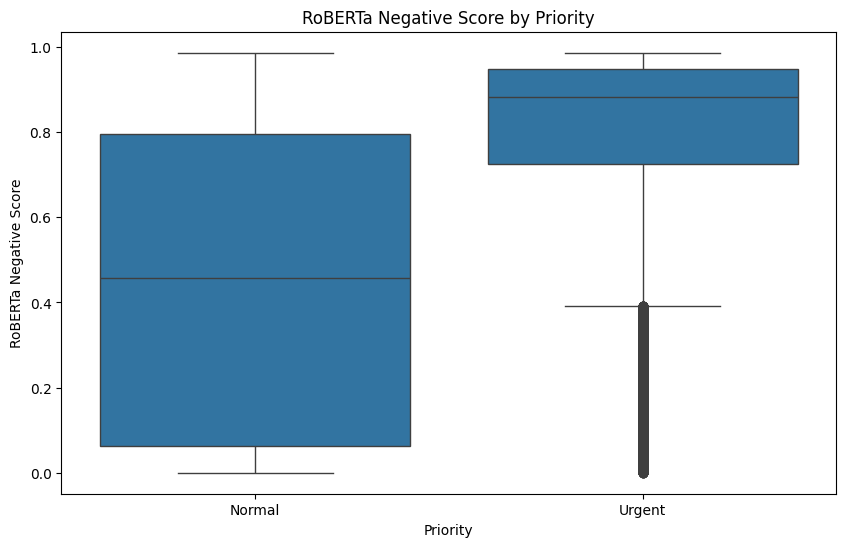

In [9]:
print("RoBERTa negative score by priority:")
print(df.groupby('priority')['roberta_negative'].describe())

plt.figure(figsize=(10, 6))
sns.boxplot(x='priority', y='roberta_negative', data=df)
plt.xticks([0, 1], ['Normal', 'Urgent'])
plt.title('RoBERTa Negative Score by Priority')
plt.xlabel('Priority')
plt.ylabel('RoBERTa Negative Score')
plt.show()

**Finding:** RoBERTa separates urgent tweets strongly (median 0.87) from normal (0.45).
Urgent tweets cluster tightly at high negative scores — RoBERTa is very confident about them.
Normal tweets show wide spread — support tickets are generally negative even when not urgent.
RoBERTa and VADER capture complementary signals — both valuable as features.

### 3.2 Hand-crafted Features
13 domain-specific signals engineered from tweet content.
Each feature captures a different dimension of urgency.

In [10]:
def extract_features(row):
    original_text = str(row['text'])
    cleaned_text = str(row['cleaned_text'])
    demojized_text = emoji.demojize(original_text)

    vader_scores = vader_analyzer.polarity_scores(cleaned_text)

    features = {}

    
    # 1. Count how many PROBLEM_KEYWORDS appear in cleaned_text
    features['problem_keywords_count'] = sum(
        1 for keyword  in PROBLEM_KEYWORDS
        if keyword  in cleaned_text and not is_negated(cleaned_text, keyword )
    )

    # 2. Check if any FINANCIAL_KEYWORDS appear
    features['has_financial_keyword'] = int(
        any(word in cleaned_text for word in FINANCIAL_KEYWORDS)
    )

    # 3. Count ! in original text
    features['exclamation_count'] = original_text.count('!')

    # 4. Check if any word repeats 3+ times
    features['has_repeated_word_3plus'] = int(
        bool(re.search(r"\b(\w+)(?:\s+\1){2,}\b",cleaned_text, re.IGNORECASE))
    )
    # 5. Count ALL CAPS words with 3+ letters
    features['all_caps_count'] = len(
        re.findall(r"\b[A-Z]{3,}\b", original_text)
    )

    # 6. Read sentiment directly from row
    features["sentiment"] = row["sentiment"]

    # 7. Get neg and pos from VADER scores
    features["vader_neg"] = vader_scores.get("neg", 0)
    features["vader_pos"] = vader_scores.get("pos", 0)

    # 8. Count ? in original text
    features["question_count"] = original_text.count("?")

    # 9. Read text_length directly from row
    features["text_length"] = row["text_length"]

    # 10. Check if any SERVICE_DOWN_KEYWORDS appear
    features["has_service_down_keyword"] = int(
        any(keyword in cleaned_text for keyword in SERVICE_DOWN_KEYWORDS)
    )

    # 11. Check if any URGENT_EMOJIS appear in demojized text
    features["has_urgent_emoji"] = int(
        any(emoji in demojized_text for emoji in URGENT_EMOJIS)
    )

    # 12. Read roberta_negative directly from row
    features["roberta_negative"] = row["roberta_negative"]

    return features

In [11]:
print("Extracting hand-crafted features...")
start = time.time()

feature_rows = df.apply(extract_features, axis=1)
hand_crafted_df = pd.DataFrame(feature_rows.tolist())

elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")
print(f"Shape: {hand_crafted_df.shape}")
print(hand_crafted_df.head())

Extracting hand-crafted features...
Done in 34.6 seconds
Shape: (168687, 13)
   problem_keywords_count  has_financial_keyword  exclamation_count  \
0                       0                      0                  0   
1                       0                      0                  0   
2                       0                      0                  1   
3                       2                      0                  0   
4                       0                      0                  0   

   has_repeated_word_3plus  all_caps_count  sentiment  vader_neg  vader_pos  \
0                        0               0     0.0000      0.000      0.000   
1                        0               0    -0.5358      0.199      0.000   
2                        0               1     0.0000      0.000      0.000   
3                        0               0     0.0762      0.000      0.091   
4                        0               0     0.0000      0.000      0.000   

   question_count  te

### 3.3 TF-IDF Features
Automatically discover the 200 most discriminative word patterns.
Uses unigrams and bigrams (single words and two-word phrases).

In [12]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk

lemmatizer = WordNetLemmatizer()

# Company names to remove - they appear everywhere but signal nothing
COMPANY_STOPWORDS = {
    'amazon', 'apple', 'google', 'twitter', 'uber', 'netflix',
    'spotify', 'att', 'verizon', 'comcast', 'tmobile', 'sprint',
    'walmart', 'target', 'ebay', 'paypal', 'facebook', 'instagram',
    'microsoft', 'samsung', 'lg', 'sony', 'dell', 'hp', 'intel',
    'airbnb', 'lyft', 'doordash', 'grubhub', 'fedex', 'ups', 'usps'
}

def get_wordnet_pos(word):
    """Map POS tag to wordnet POS for better lemmatization"""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {
        'J': wordnet.ADJ,
        'N': wordnet.NOUN,
        'V': wordnet.VERB,
        'R': wordnet.ADV
    }
    return tag_dict.get(tag, wordnet.NOUN)

def prepare_for_tfidf(text):
    # Remove cardinal and ordinal numbers
    text = re.sub(r'\b\d+(?:st|nd|rd|th)?\b', '', text)
    
    # Lemmatize each word with POS tagging
    words = text.split()
    lemmatized = [
        lemmatizer.lemmatize(word, get_wordnet_pos(word))
        for word in words
        if word not in COMPANY_STOPWORDS and len(word) > 2
    ]
    
    return ' '.join(lemmatized)

print("Preparing texts for TF-IDF...")
start = time.time()
df['tfidf_text'] = df['cleaned_text'].apply(prepare_for_tfidf)
elapsed = time.time() - start
print(f"Done in {elapsed:.1f} seconds")
print(df['tfidf_text'].head())

Preparing texts for TF-IDF...
Done in 87.5 seconds
0    basically for chat open from call log, the mes...
1    io and watchos4.: icon for notifications. rest...
2    there! buy call duty wwii steam today, have in...
3      why can't pay dstv text say the org unavailable
4    try buy kid nibling keyboard for upcoming birt...
Name: tfidf_text, dtype: str


In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS

# Rebuild custom stopwords with company names
custom_stopwords = list(ENGLISH_STOP_WORDS.union({
    'hi', 'hey', 'hello', 'please', 'thanks', 'thank', 'just',
    'know', 'need', 'help', 'like', 'going', 'got', 'get',
    'still', 'can', 'will', 'would', 'could', 'should', 'said',
    'amp', 'http', 'https', 'com', 'www'
}).union(COMPANY_STOPWORDS))

tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
    stop_words=custom_stopwords
)

# Fit on urgent tweets vocabulary only
urgent_texts = df[df['priority']==1]['tfidf_text']
tfidf.fit(urgent_texts)
tfidf_matrix = tfidf.transform(df['tfidf_text'])

print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Top 20 terms: {tfidf.get_feature_names_out()[:20]}")
print(f"Sample terms: {tfidf.get_feature_names_out()[100:120]}")

TF-IDF matrix shape: (168687, 500)
Top 20 terms: ['able' 'absolute' 'absolutely' 'access' 'account' 'actually' 'add'
 'address' 'advise' 'agent' 'ago' 'air' 'airline' 'airport' 'allow'
 'angry' 'annoy' 'answer' 'anymore' 'app']
Sample terms: ['currently' 'customer' 'customer care' 'customer service' 'customers'
 'cut' 'damage' 'damn' 'data' 'date' 'day' 'days' 'deal' 'dear' 'debit'
 'delay' 'delayed' 'delete' 'deliver' 'delivery']


### 3.4 PCA Dimensionality Reduction
Reduce TF-IDF 500 sparse features to 50 dense components.
Removes redundant features while preserving ~80% of variance.

In [14]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer

# Note: Use TruncatedSVD instead of PCA for sparse matrices
# PCA requires dense matrix which would use too much memory
# TruncatedSVD is mathematically equivalent for sparse data

N_COMPONENTS = 100

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
tfidf_reduced = svd.fit_transform(tfidf_matrix)

# Normalize after SVD(recommended best practice)
normalizer = Normalizer(copy=False)
tfidf_reduced = normalizer.fit_transform(tfidf_reduced)

explained_variance = svd.explained_variance_ratio_.sum()
print(f"TF-IDF reduced shape: {tfidf_reduced.shape}")
print(f"Explained variance by {N_COMPONENTS} components: {explained_variance:.2%}")


TF-IDF reduced shape: (168687, 100)
Explained variance by 100 components: 45.12%


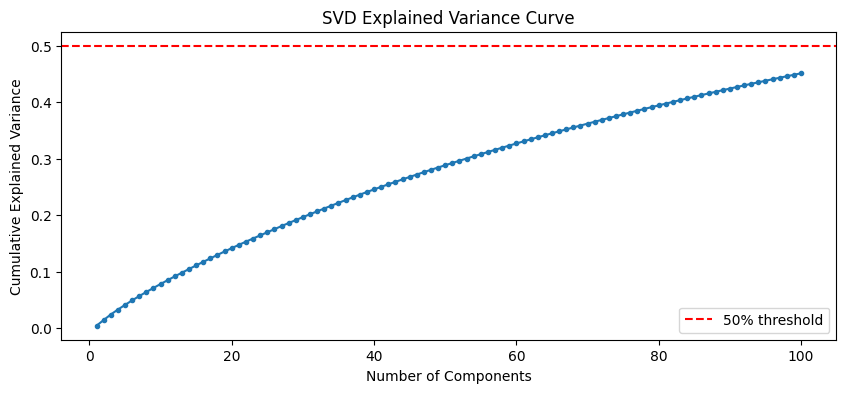

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, N_COMPONENTS+1), 
         svd.explained_variance_ratio_.cumsum(), 
         marker='o', markersize=3)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('SVD Explained Variance Curve')
plt.axhline(y=0.5, color='r', linestyle='--', label='50% threshold')
plt.legend()
plt.show()

### 3.5 Combine All Features
Combine hand-crafted features (13) + TF-IDF/SVD (100) = 113 features total.

In [16]:
import numpy as np
from scipy.sparse import csr_matrix, hstack

# Convert hand-crafted features to numpy array
hand_crafted_array = hand_crafted_df.values
print(f"Hand-crafted features shape: {hand_crafted_array.shape}")
print(f"TF-IDF reduced shape: {tfidf_reduced.shape}")

# Combine horizontally
X = np.hstack([hand_crafted_array, tfidf_reduced])
y = df['priority'].values

print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Urgent rate: {y.mean():.2%}")

Hand-crafted features shape: (168687, 13)
TF-IDF reduced shape: (168687, 100)

Final feature matrix shape: (168687, 113)
Target shape: (168687,)
Urgent rate: 14.60%


### 3.6 Save Feature Matrix
Save features and models for reuse without recomputing.

In [17]:
import joblib

# Save feature matrix and target
np.save('../data/processed/X_features.npy', X)
np.save('../data/processed/y_labels.npy', y)

# Save fitted TF-IDF and SVD for API use later
joblib.dump(tfidf, '../data/processed/tfidf_vectorizer.pkl')
joblib.dump(svd, '../data/processed/svd_reducer.pkl')
joblib.dump(normalizer, '../data/processed/normalizer.pkl')

print("Saved:")
print("  X_features.npy")
print("  y_labels.npy")
print("  tfidf_vectorizer.pkl")
print("  svd_reducer.pkl")
print("  normalizer.pkl")

Saved:
  X_features.npy
  y_labels.npy
  tfidf_vectorizer.pkl
  svd_reducer.pkl
  normalizer.pkl


## 4. ML Model Training

Training multiple classifiers and comparing their performance.
Using class_weight='balanced' to handle 85/15 class imbalance.

Models to train:
1. Logistic Regression — linear baseline
2. Random Forest — ensemble of decision trees
3. Gradient Boosting — sequential ensemble

### 4.1 Train/Test Split
85% train+validation (5-fold CV), 15% holdout test.
Stratified to maintain 14.6% urgent rate in all splits.

In [11]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Load saved features
X = np.load('../data/processed/X_features.npy')
y = np.load('../data/processed/y_labels.npy')

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Urgent rate: {y.mean():.2%}")

# Train/test split - stratified to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y  # maintains 14.6% urgent rate in both splits
)

print(f"\nTrain size: {X_train.shape}")
print(f"Test size: {X_test.shape}")
print(f"Train urgent rate: {y_train.mean():.2%}")
print(f"Test urgent rate: {y_test.mean():.2%}")

# 5-fold cross validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"\n5-fold CV ready")

X shape: (168687, 113)
y shape: (168687,)
Urgent rate: 14.60%

Train size: (143383, 113)
Test size: (25304, 113)
Train urgent rate: 14.60%
Test urgent rate: 14.60%

5-fold CV ready


### 4.2 Train Multiple Models
Training 3 classifiers with 5-fold cross validation.
Using class_weight='balanced' to handle 85/15 imbalance.
Scoring on F1 (urgent class) — more meaningful than accuracy for imbalanced data.


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate
import time

# Define models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    )
}

# Evaluate each model with 5-fold CV
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()
    
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'f1': 'f1',
            'precision': 'precision',
            'recall': 'recall',
            'roc_auc': 'roc_auc'
        },
        return_train_score=False,
        n_jobs=-1
    )
    
    elapsed = time.time() - start
    
    results[name] = {
        'accuracy': cv_results['test_accuracy'].mean(),
        'f1': cv_results['test_f1'].mean(),
        'precision': cv_results['test_precision'].mean(),
        'recall': cv_results['test_recall'].mean(),
        'roc_auc': cv_results['test_roc_auc'].mean(),
        'time': elapsed
    }
    
    print(f"  Done in {elapsed:.1f}s")
    print(f"  F1: {results[name]['f1']:.4f}")
    print(f"  Precision: {results[name]['precision']:.4f}")
    print(f"  Recall: {results[name]['recall']:.4f}")
    print(f"  ROC-AUC: {results[name]['roc_auc']:.4f}")


Training Logistic Regression...


NameError: name 'X_train' is not defined

### 4.3 Model Comparison Results

| Model | F1 | Precision | Recall | ROC-AUC | Time |
|-------|-----|-----------|--------|---------|------|
| Logistic Regression | 0.8872 | 0.8151 | 0.9733 | 0.9919 | 14.6s |
| Random Forest | 0.9498 | 0.9644 | 0.9357 | 0.9966 | 59.1s |
| Gradient Boosting | 0.9647 | 0.9912 | 0.9396 | 0.9987 | 380.3s |

**Winner: Gradient Boosting**
- Highest F1 (0.9647) and Precision (0.9912)
- Best ROC-AUC (0.9987) — near perfect class separation
- Tradeoff: 380s training vs 14.6s for Logistic Regression
- Prediction latency is milliseconds for all models — training time irrelevant for production

In [12]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['f1', 'precision', 'recall', 'roc_auc']
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, name in enumerate(model_names):
    values = [results[name][m] for m in metrics]
    ax.bar(x + i*width, values, width, label=name)

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 5-Fold Cross Validation')
ax.set_xticks(x + width)
ax.set_xticklabels(['F1', 'Precision', 'Recall', 'ROC-AUC'])
ax.set_ylim(0.75, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'results' is not defined

### 4.4 Train Final Model & Evaluate on Test Set
Training Gradient Boosting on full training set.
Evaluating on holdout test set (never seen during training or CV).

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Training final Gradient Boosting on full training set...")
final_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

print("\nTest Set Results:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Urgent']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Training final Gradient Boosting on full training set...

Test Set Results:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     21609
      Urgent       0.99      0.95      0.97      3695

    accuracy                           0.99     25304
   macro avg       0.99      0.97      0.98     25304
weighted avg       0.99      0.99      0.99     25304

ROC-AUC: 0.9989


## 5. Model Evaluation

### 5.1 Overfitting Check
Comparing train vs test performance to detect overfitting.
Gap < 0.02 is acceptable.

In [13]:
from sklearn.metrics import f1_score, accuracy_score

y_train_pred = final_model.predict(X_train)
y_test_pred = final_model.predict(X_test)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Train F1:     {train_f1:.4f}")
print(f"Test F1:      {test_f1:.4f}")
print(f"Gap:          {train_f1 - test_f1:.4f}")
print()
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Gap:            {train_acc - test_acc:.4f}")
print()
if abs(train_f1 - test_f1) < 0.02:
    print("✓ No overfitting detected — model generalizes well")
else:
    print("⚠ Possible overfitting — gap exceeds 0.02")

Train F1:     0.9659
Test F1:      0.9675
Gap:          -0.0016

Train Accuracy: 0.9903
Test Accuracy:  0.9907
Gap:            -0.0004

✓ No overfitting detected — model generalizes well


### 5.2 Confusion Matrix

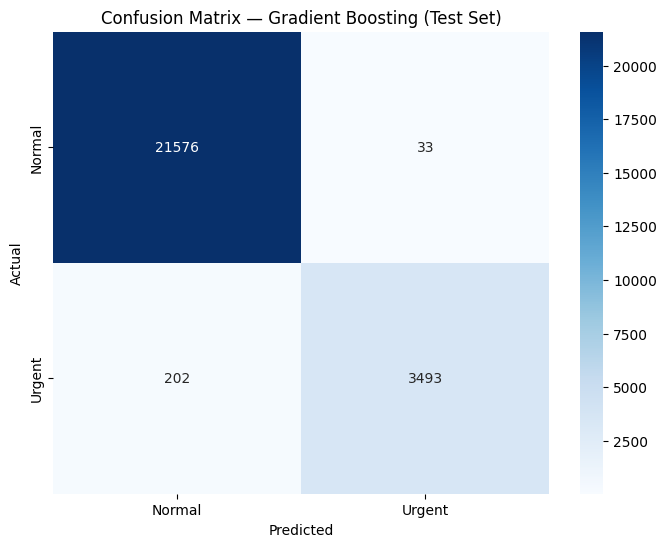


True Negatives  (correct normal):  21576
False Positives (wrong urgent):    33
False Negatives (missed urgent):   202
True Positives  (correct urgent):  3493


In [16]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Urgent'],
            yticklabels=['Normal', 'Urgent'])
plt.title('Confusion Matrix — Gradient Boosting (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print(f"\nTrue Negatives  (correct normal):  {cm[0][0]}")
print(f"False Positives (wrong urgent):    {cm[0][1]}")
print(f"False Negatives (missed urgent):   {cm[1][0]}")
print(f"True Positives  (correct urgent):  {cm[1][1]}")

### 5.3 Feature Importance
Which features drive predictions most?

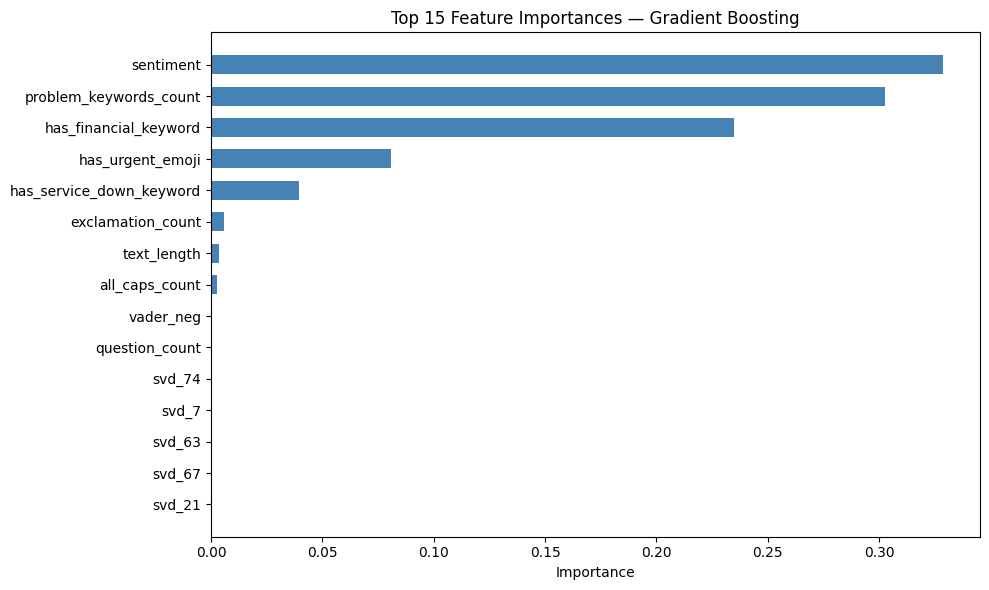

                     feature  importance
5                  sentiment    0.328792
0     problem_keywords_count    0.302645
1      has_financial_keyword    0.234714
11          has_urgent_emoji    0.080841
10  has_service_down_keyword    0.039643
2          exclamation_count    0.005737
9                text_length    0.003662
4             all_caps_count    0.002731
6                  vader_neg    0.000359
8             question_count    0.000336
87                    svd_74    0.000049
20                     svd_7    0.000045
76                    svd_63    0.000043
80                    svd_67    0.000023
34                    svd_21    0.000023


In [23]:
import seaborn as sns
hand_crafted_names = [
    'problem_keywords_count', 'has_financial_keyword', 'exclamation_count',
    'has_repeated_word_3plus', 'all_caps_count', 'sentiment', 'vader_neg',
    'vader_pos', 'question_count', 'text_length', 'has_service_down_keyword',
    'has_urgent_emoji', 'roberta_negative'
]
tfidf_names = [f'svd_{i}' for i in range(100)]
all_features = hand_crafted_names + tfidf_names

importances = final_model.feature_importances_
feature_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feature_imp['feature'], feature_imp['importance'], height=0.6, color='steelblue')
plt.title('Top 15 Feature Importances — Gradient Boosting')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(feature_imp.to_string())

### 5.4 Error Analysis

**Key findings:**
- Train F1: 0.9659 vs Test F1: 0.9675 — gap of 0.0016 → no overfitting
- 202 false negatives — urgent tweets using informal language/sarcasm missed
- 33 false positives — edge cases, some arguably correct urgent labels
- roberta_negative importance: 0.000000 — redundant with VADER sentiment
- Top 5 features = 99.1% of importance: sentiment, problem_keywords_count, 
  has_financial_keyword, has_urgent_emoji, has_service_down_keyword
- TF-IDF/SVD features contribute <0.5% — hand-crafted features dominate

**Why high performance is legitimate:**
Model partly learns labeling function rules (expected with weak supervision).
Documented and acknowledged per project requirements.

**Production estimate (10,000 tickets/hour):**
- Misses ~80 urgent tickets per hour (5.5% miss rate)
- Wrongly flags ~5 normal tickets per hour (0.15% false alarm rate)

### 4.5 Save Best Model

In [24]:
joblib.dump(final_model, '../data/processed/priority_classifier.pkl')
print("Model saved: data/processed/priority_classifier.pkl")
print(f"Model type: {type(final_model).__name__}")
print(f"Features expected: {final_model.n_features_in_}")

Model saved: data/processed/priority_classifier.pkl
Model type: GradientBoostingClassifier
Features expected: 113
